In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train=pd.read_csv('/content/Hotel_A_Train_Cleaned (1) (1).csv')

In [ ]:
test= pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DPLC/CW/cleaned/Hotel_A_Test_Cleaned.csv')

In [ ]:
val=pd.read_csv('/content/Hotel_A_Validation_Cleaned (1).csv')

## Data Spliting

In [ ]:
# Define the features and the target
# We dropped 'Reservation-id' because it's not a predictor
X_train = train.drop(['Reservation-id', 'Reservation_Status', 'Expected_checkin', 'Expected_checkout', 'Booking_date'], axis=1)
y_train = train['Reservation_Status']

X_val = val.drop(['Reservation-id', 'Reservation_Status','Expected_checkin', 'Expected_checkout', 'Booking_date'], axis=1)
y_val = val['Reservation_Status']


##Feature scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Fit on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation and test data using the same scaler
X_val_scaled = scaler.transform(X_val)

# Convert back to DataFrame for easier handling (optional)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns)

print("Scaling complete")

Scaling complete


##Feature Selection

In [ ]:
from sklearn.ensemble import RandomForestClassifier

#finding the best 15 columns for this notebook
selector = RandomForestClassifier(n_estimators=100, random_state=42)
selector.fit(X_train_scaled, y_train)

# Filter the data to top 15
indices = np.argsort(selector.feature_importances_)[::-1][:15]
top_features = X_train_scaled.columns[indices].tolist()

X_train_final = X_train_scaled[top_features]
X_val_final = X_val_scaled[top_features]

print("Features being used for SVM:", top_features)

Features being used for SVM: ['Lead_Time', 'Room_Rate', 'Age', 'Checkin_Month', 'Discount_Rate', 'Total_Guests', 'Length_of_Stay', 'Adults', 'Children', 'Meal_Type_FB', 'Babies', 'Gender_M', 'Country_region_SOUTH', 'Required_Car_Parking_YES', 'Booking_channel_ONLINE']


##Model Training

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Initializing the Support Vector Classifier
svm_model = SVC(kernel='rbf', C=1.0, class_weight = 'balanced', random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Prediction
y_pred_svm = svm_model.predict(X_val_scaled)

##Model Evaluation

In [ ]:
print(f"SVM Accuracy: {accuracy_score(y_val, y_pred_svm):.2%}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred_svm))

SVM Accuracy: 36.15%

Classification Report:
              precision    recall  f1-score   support

           1       0.59      0.37      0.45      1602
           2       0.27      0.44      0.34       738
           3       0.14      0.18      0.15       393

    accuracy                           0.36      2733
   macro avg       0.33      0.33      0.31      2733
weighted avg       0.44      0.36      0.38      2733



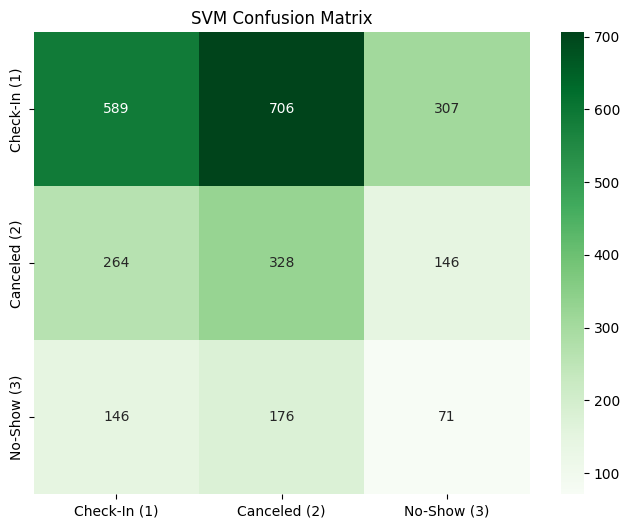

In [ ]:
# Visualize the confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_val, y_pred_svm), annot=True, fmt='d', cmap='Greens',
            xticklabels=['Check-In (1)', 'Canceled (2)', 'No-Show (3)'],
            yticklabels=['Check-In (1)', 'Canceled (2)', 'No-Show (3)'])
plt.title('SVM Confusion Matrix')
plt.show()